<a href="https://colab.research.google.com/github/islam3ouf/Linear-Algebra-Visualization-With-Python/blob/main/01-Vector-Visualization/animated_vector_visualization_py.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving animation...
 Animation Saved Successfully!


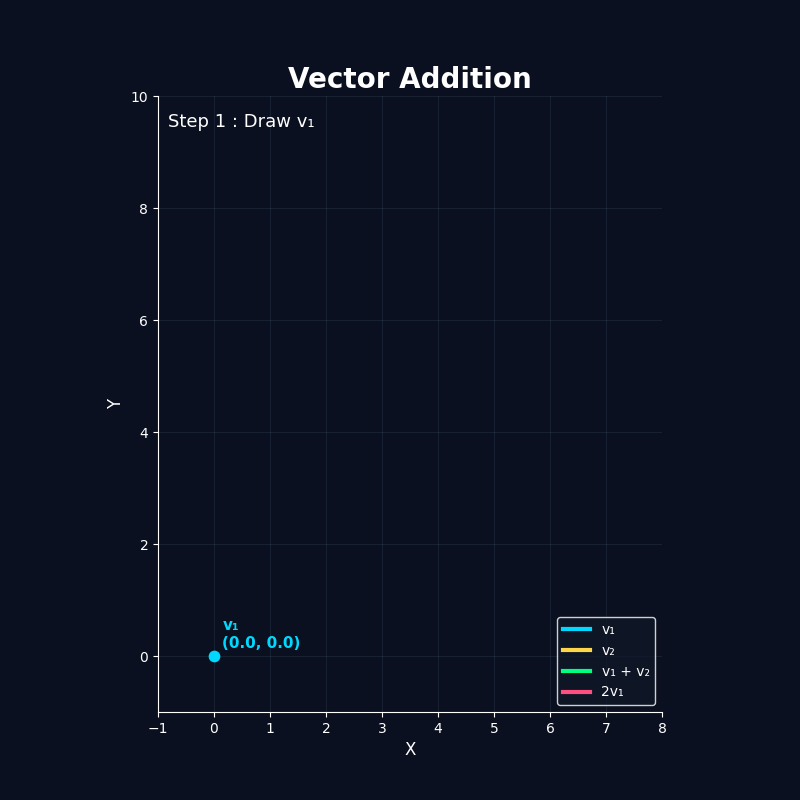

In [1]:

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib.lines import Line2D
from IPython.display import Image

# ============================================================
# DATA
# ============================================================

v1 = np.array([2, 3])
v2 = np.array([3, 1])

v_sum = v1 + v2
v1_double = 2 * v1

# ============================================================
# COLORS
# ============================================================

BG = "#0B1020"
GRID = "#334155"

C1 = "#00D9FF"      # v₁
C2 = "#FFD54A"      # v₂
CSUM = "#00FF7F"    # v₁ + v₂
CSCALE = "#FF4F81"  # 2v₁

# ============================================================
# FIGURE
# ============================================================

fig, ax = plt.subplots(figsize=(8,8))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

# ============================================================
# STYLE
# ============================================================

def style_axes():

    ax.set_xlim(-1,8)
    ax.set_ylim(-1,10)
    ax.set_aspect("equal")

    ax.grid(
        True,
        color=GRID,
        alpha=0.35,
        linewidth=0.8
    )

    ax.spines["left"].set_color("white")
    ax.spines["bottom"].set_color("white")
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)

    ax.tick_params(colors="white")

    ax.set_xlabel("X", color="white", fontsize=12)
    ax.set_ylabel("Y", color="white", fontsize=12)

# ============================================================
# DRAW VECTOR
# ============================================================

def draw_vector(vec, color, label, alpha=1, finished=False):

    ax.arrow(
        0,
        0,
        vec[0],
        vec[1],
        color=color,
        linewidth=3.5,
        head_width=0.20,
        head_length=0.30,
        length_includes_head=True,
        alpha=alpha
    )

    ax.scatter(
        vec[0],
        vec[1],
        s=55,
        color=color,
        alpha=alpha,
        zorder=5
    )

    # ===== النص =====

    if finished:
        text = f"{label}\n({int(round(vec[0]))}, {int(round(vec[1]))})"
    else:
        text = f"{label}\n({vec[0]:.1f}, {vec[1]:.1f})"

    ax.text(
        vec[0] + 0.15,
        vec[1] + 0.15,
        text,
        color=color,
        fontsize=11,
        weight="bold"
    )

# ============================================================
# TAIL TO HEAD
# ============================================================

def tail_to_head():

    ax.arrow(
        v1[0],
        v1[1],
        v2[0],
        v2[1],
        linestyle="--",
        linewidth=2,
        color=C2,
        alpha=0.55,
        head_width=0.15,
        length_includes_head=True
    )

# ============================================================
# LEGEND
# ============================================================

legend = [
    Line2D([0],[0],color=C1,lw=3),
    Line2D([0],[0],color=C2,lw=3),
    Line2D([0],[0],color=CSUM,lw=3),
    Line2D([0],[0],color=CSCALE,lw=3),
]

# ============================================================
# TOTAL FRAMES
# ============================================================

TOTAL_FRAMES = 360

# ============================================================
# ANIMATION
# ============================================================

def animate(frame):

    ax.clear()
    ax.set_facecolor(BG)
    style_axes()

    ax.legend(
        handles=legend,
        labels=["v₁", "v₂", "v₁ + v₂", "2v₁"],
        loc="lower right",
        facecolor="#101828",
        edgecolor="white",
        fontsize=10,
        labelcolor="white"
    )

    # -------------------------------------------------------
    # 1) Draw v1
    # -------------------------------------------------------

    if frame < 40:

        t = frame / 40

        draw_vector(
            v1 * t,
            C1,
            "v₁"
        )

        ax.set_title(
            "Vector Addition",
            fontsize=20,
            color="white",
            weight="bold"
        )

        ax.text(
            0.02,
            0.95,
            "Step 1 : Draw v₁",
            transform=ax.transAxes,
            color="white",
            fontsize=13
        )

    # -------------------------------------------------------
    # 2) Draw v2
    # -------------------------------------------------------

    elif frame < 80:

        draw_vector(v1, C1, "v₁", finished=True)

        t = (frame - 40) / 40

        draw_vector(
            v2 * t,
            C2,
            "v₂"
        )

        ax.set_title(
            "Vector Addition",
            fontsize=20,
            color="white",
            weight="bold"
        )

        ax.text(
            0.02,
            0.95,
            "Step 2 : Draw v₂",
            transform=ax.transAxes,
            color="white",
            fontsize=13
        )

    # -------------------------------------------------------
    # 3) Tail to Head
    # -------------------------------------------------------

    elif frame < 120:

        draw_vector(v1, C1, "v₁", finished=True)
        draw_vector(v2, C2, "v₂", finished=True)

        tail_to_head()

        ax.set_title(
            "Tail-to-Head Rule",
            fontsize=20,
            color="white",
            weight="bold"
        )

        ax.text(
            0.02,
            0.95,
            "Move v₂ to the head of v₁",
            transform=ax.transAxes,
            color="white",
            fontsize=13
        )

    # -------------------------------------------------------
    # 4) Draw Sum
    # -------------------------------------------------------

    elif frame < 160:

        draw_vector(v1, C1, "v₁", finished=True)
        draw_vector(v2, C2, "v₂", finished=True)

        tail_to_head()

        t = (frame - 120) / 40

        draw_vector(
            v_sum * t,
            CSUM,
            "v₁+v₂"
        )

        ax.set_title(
            "Vector Addition",
            fontsize=20,
            color="white",
            weight="bold"
        )

        ax.text(
            0.02,
            0.95,
            "v₁ + v₂ = (5,4)",
            transform=ax.transAxes,
            color="white",
            fontsize=13
        )

    # -------------------------------------------------------
    # 5) Pause
    # -------------------------------------------------------

    elif frame < 200:

        draw_vector(v1, C1, "v₁", finished=True)
        draw_vector(v2, C2, "v₂", finished=True)
        draw_vector(v_sum, CSUM, "v₁+v₂", finished=True)

        tail_to_head()

        ax.set_title(
            "Vector Addition Complete",
            fontsize=20,
            color="white",
            weight="bold"
        )

    # -------------------------------------------------------
    # 6) Fade
    # -------------------------------------------------------

    elif frame < 220:

        alpha = 1 - (frame - 200) / 20

        draw_vector(v1, C1, "v₁", alpha=alpha, finished=True)
        draw_vector(v2, C2, "v₂", alpha=alpha, finished=True)
        draw_vector(v_sum, CSUM, "v₁+v₂", alpha=alpha, finished=True)

        ax.set_title(
            "Transition...",
            fontsize=20,
            color="white",
            weight="bold"
        )

    # -------------------------------------------------------
    # 7) Scalar Multiplication
    # -------------------------------------------------------

    elif frame < 260:

        draw_vector(v1, C1, "v₁", finished=True)

        ax.set_title(
            "Scalar Multiplication",
            fontsize=20,
            color="white",
            weight="bold"
        )

        ax.text(
            0.02,
            0.95,
            "Multiply v₁ by 2",
            transform=ax.transAxes,
            color="white",
            fontsize=13
        )

    # -------------------------------------------------------
    # 8) Grow to 2v₁ (Slow Smooth)
    # -------------------------------------------------------

    elif frame < 320:

        t = (frame - 260) / 60
        t = 3*t**2 - 2*t**3

        vec = v1 + (v1_double - v1) * t

        draw_vector(
            vec,
            CSCALE,
            "2v₁"
        )

        ax.set_title(
            "Scalar Multiplication",
            fontsize=20,
            color="white",
            weight="bold"
        )

        ax.text(
            0.02,
            0.95,
            "2 × v₁ = (4,6)",
            transform=ax.transAxes,
            color="white",
            fontsize=13
        )

    # -------------------------------------------------------
    # 9) Final Pause
    # -------------------------------------------------------

    else:

        draw_vector(
            v1_double,
            CSCALE,
            "2v₁",
            finished=True
        )

        ax.set_title(
            "Scalar Multiplication Complete",
            fontsize=20,
            color="white",
            weight="bold"
        )

        ax.text(
            0.02,
            0.95,
            "2 × v₁ = (4,6)",
            transform=ax.transAxes,
            color="white",
            fontsize=13
        )

# ============================================================
# CREATE ANIMATION
# ============================================================

ani = FuncAnimation(
    fig,
    animate,
    frames=TOTAL_FRAMES,
    interval=40,
    repeat=True,
    repeat_delay=1500,
    blit=False
)

# ============================================================
# SAVE GIF
# ============================================================

print("Saving animation...")

gif_writer = PillowWriter(
    fps=25
)

ani.save(
    "vector_operations.gif",
    writer=gif_writer
)

# ============================================================
# OPTIONAL MP4 (Requires ffmpeg)
# ============================================================

"""
from matplotlib.animation import FFMpegWriter

writer = FFMpegWriter(
    fps=30,
    bitrate=3000
)

ani.save(
    "vector_operations.mp4",
    writer=writer
)
"""

# ============================================================
# CLEANUP
# ============================================================

plt.close(fig)

print("=" * 50)
print(" Animation Saved Successfully!")
print("=" * 50)

Image("vector_operations.gif")